# Random Forest Baseline

**Purpose.** Compare tree-depth and leaf-size variants on aggregated NumPy MFCC features.

This is a self-contained coursework notebook. It does not import custom helper modules and does not depend on another notebook. It defaults to a small `smoke` run; switch `RUN_MODE` to `final` only after the smoke run succeeds.

Results and takeaways must be written from executed outputs. No performance claims are pre-filled.

## Goal

Build a reproducible five-generator attribution experiment with a held-out test split.

## Setup

The configuration cell is the only cell normally edited in Colab.

In [1]:
# Install only missing packages. Neural-network notebooks do not install or use
# TensorFlow, PyTorch, Keras, or scikit-learn neural-network implementations.
import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}
missing = [pip_name for module, pip_name in required_packages.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
print("Environment ready.")

Environment ready.


In [2]:
import copy
import hashlib
import json
import math
import os
import random
import time
import warnings
import zipfile
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy.signal import resample_poly

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

IN_COLAB = (
    importlib.util.find_spec("google") is not None
    and importlib.util.find_spec("google.colab") is not None
)
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    default_root = Path("/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI")
else:
    default_root = Path.cwd()
    if not (default_root / "Fake Music Caps.zip").exists() and (default_root.parent / "Fake Music Caps.zip").exists():
        default_root = default_root.parent

# These environment variables provide a local-test override without changing
# the Colab defaults shown to a coursework reader.
PROJECT_ROOT = Path(os.environ.get("PROGMATHSAI_PROJECT_ROOT", str(default_root)))
ZIP_PATH = Path(os.environ.get("FAKEMUSICCAPS_ZIP_PATH", str(PROJECT_ROOT / "Datasets" / "Fake Music Caps.zip")))
DATA_DIR = Path(os.environ.get("FAKEMUSICCAPS_DATA_DIR", str(PROJECT_ROOT / "Datasets" / "Fake Music Caps")))
OUTPUT_ROOT = Path(os.environ.get("FAKEMUSICCAPS_OUTPUT_ROOT", str(PROJECT_ROOT / "task1_outputs")))

RUN_MODE = os.environ.get("FAKEMUSICCAPS_RUN_MODE", "smoke").lower()
if RUN_MODE not in {"smoke", "final"}:
    raise ValueError("RUN_MODE must be 'smoke' or 'final'.")

MODEL_TAG = "random_forest"
OUTPUT_DIR = OUTPUT_ROOT / MODEL_TAG
FIGURES_DIR = OUTPUT_DIR / "figures"
METRICS_DIR = OUTPUT_DIR / "metrics"
MODELS_DIR = OUTPUT_DIR / "models"
TABLES_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = OUTPUT_DIR / "cache"
for directory in (FIGURES_DIR, METRICS_DIR, MODELS_DIR, TABLES_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

FOLDER_TO_LABEL = {
    "audioldm2": 0,
    "MusicGen_medium": 1,
    "musicldm": 2,
    "mustango": 3,
    "stable_audio_open": 4,
}
CLASS_NAMES = ["AudioLDM2", "MusicGen", "MusicLDM", "Mustango", "Stable Audio Open"]

SAMPLE_RATE = 16_000
CLIP_SECONDS = 2.5
FRAME_MS = 25
HOP_MS = 10
N_FFT = 512
N_MELS = 26
N_MFCC = 20
POOL_FACTOR = 4
SMOKE_PER_CLASS_PER_SPLIT = 8

print({
    "run_mode": RUN_MODE,
    "project_root": str(PROJECT_ROOT),
    "zip_path": str(ZIP_PATH),
    "data_dir": str(DATA_DIR),
    "output_dir": str(OUTPUT_DIR),
})

Mounted at /content/drive
{'run_mode': 'smoke', 'project_root': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI', 'zip_path': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/Datasets/Fake Music Caps.zip', 'data_dir': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/Datasets/Fake Music Caps', 'output_dir': '/content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/random_forest'}


## Data

Track IDs, rather than individual generated files, determine the split. Each split is balanced independently.

In [3]:
def ensure_dataset_available():
    """Extract the archive only when the configured data directory is absent."""
    if DATA_DIR.exists():
        return DATA_DIR
    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"Dataset folder not found at {DATA_DIR} and ZIP not found at {ZIP_PATH}. "
            "Update the configuration cell or upload the ZIP to Google Drive."
        )
    print(f"Extracting {ZIP_PATH.name}; this is a one-time operation...")
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR.parent)
    if not DATA_DIR.exists():
        raise FileNotFoundError(f"Archive extracted, but expected folder was not created: {DATA_DIR}")
    return DATA_DIR


def scan_dataset():
    root = ensure_dataset_available()
    missing_folders = [folder for folder in FOLDER_TO_LABEL if not (root / folder).is_dir()]
    if missing_folders:
        raise FileNotFoundError(f"Missing expected generator folders: {missing_folders}")

    rows = []
    for folder, label in FOLDER_TO_LABEL.items():
        paths = sorted((root / folder).glob("*.wav"))
        if not paths:
            raise ValueError(f"No WAV files found in {root / folder}")
        for path in paths:
            rows.append({
                "path": str(path),
                "track_id": path.stem,
                "folder": folder,
                "label": label,
                "class_name": CLASS_NAMES[label],
            })

    manifest = pd.DataFrame(rows)
    if manifest["path"].duplicated().any():
        raise AssertionError("Duplicate file paths found in the manifest.")
    valid_track_ids = manifest["track_id"].str.fullmatch(r"[A-Za-z0-9_-]{11}")
    if not valid_track_ids.all():
        invalid = manifest.loc[~valid_track_ids, "track_id"].drop_duplicates().head(10).tolist()
        raise ValueError(
            "Expected every WAV stem to be an 11-character track ID containing only "
            f"letters, digits, '_' or '-'. Invalid examples: {invalid}"
        )
    return manifest.sort_values(["track_id", "label"]).reset_index(drop=True)


def split_for_track_id(track_id, seed=RANDOM_SEED):
    # Stable across Python sessions, operating systems, and notebook order.
    digest = hashlib.sha256(f"{seed}:{track_id}".encode("utf-8")).hexdigest()
    bucket = int(digest[:8], 16) % 10_000
    if bucket < 7_000:
        return "train"
    if bucket < 8_500:
        return "validation"
    return "test"


def make_balanced_splits(manifest):
    selected_parts = []
    working = manifest.copy()
    working["split"] = working["track_id"].map(split_for_track_id)

    for split_index, split_name in enumerate(("train", "validation", "test")):
        split_df = working[working["split"] == split_name]
        counts = split_df.groupby("label").size().reindex(range(len(CLASS_NAMES)), fill_value=0)
        if (counts == 0).any():
            raise ValueError(f"At least one class is absent from {split_name}: {counts.to_dict()}")
        per_class = int(counts.min())
        if RUN_MODE == "smoke":
            per_class = min(per_class, SMOKE_PER_CLASS_PER_SPLIT)
        for label in range(len(CLASS_NAMES)):
            class_rows = split_df[split_df["label"] == label]
            selected_parts.append(class_rows.sample(
                n=per_class,
                random_state=RANDOM_SEED + split_index * 100 + label,
                replace=False,
            ))

    selected = pd.concat(selected_parts, ignore_index=True)
    selected = selected.sort_values(["split", "label", "track_id"]).reset_index(drop=True)

    id_sets = {
        split: set(selected.loc[selected["split"] == split, "track_id"])
        for split in ("train", "validation", "test")
    }
    assert id_sets["train"].isdisjoint(id_sets["validation"])
    assert id_sets["train"].isdisjoint(id_sets["test"])
    assert id_sets["validation"].isdisjoint(id_sets["test"])
    return selected


def split_summary(selected):
    return (selected.groupby(["split", "class_name"])
            .size().rename("files").reset_index())

## NumPy MFCCs

Framing, FFT, mel filters, logarithms, and the DCT are implemented explicitly with NumPy.

In [4]:
def load_wav_center_crop(path, target_sr=SAMPLE_RATE, seconds=CLIP_SECONDS):
    """Load, mono-convert, resample, and deterministically centre crop/pad a WAV."""
    sample_rate, audio = wavfile.read(path)
    if audio.ndim == 2:
        audio = audio.astype(np.float64).mean(axis=1)
    if np.issubdtype(audio.dtype, np.integer):
        scale = max(abs(np.iinfo(audio.dtype).min), np.iinfo(audio.dtype).max)
        audio = audio.astype(np.float64) / scale
    else:
        audio = audio.astype(np.float64)

    if sample_rate != target_sr:
        divisor = math.gcd(int(sample_rate), int(target_sr))
        audio = resample_poly(audio, target_sr // divisor, sample_rate // divisor)

    target_length = int(round(target_sr * seconds))
    if len(audio) >= target_length:
        start = (len(audio) - target_length) // 2
        audio = audio[start:start + target_length]
    else:
        left = (target_length - len(audio)) // 2
        right = target_length - len(audio) - left
        audio = np.pad(audio, (left, right))

    peak = np.max(np.abs(audio)) if audio.size else 0.0
    if peak > 1.0:
        audio = audio / peak
    return audio.astype(np.float32)


def hz_to_mel(frequency_hz):
    return 2595.0 * np.log10(1.0 + np.asarray(frequency_hz) / 700.0)


def mel_to_hz(mel_value):
    return 700.0 * (10.0 ** (np.asarray(mel_value) / 2595.0) - 1.0)


def mel_filter_bank(sample_rate=SAMPLE_RATE, n_fft=N_FFT, n_mels=N_MELS):
    mel_points = np.linspace(hz_to_mel(0), hz_to_mel(sample_rate / 2), n_mels + 2)
    hz_points = mel_to_hz(mel_points)
    bins = np.floor((n_fft + 1) * hz_points / sample_rate).astype(int)
    bins = np.clip(bins, 0, n_fft // 2)

    filters = np.zeros((n_mels, n_fft // 2 + 1), dtype=np.float64)
    for index in range(1, n_mels + 1):
        left, centre, right = bins[index - 1:index + 2]
        centre = max(centre, left + 1)
        right = max(right, centre + 1)
        for frequency_bin in range(left, min(centre, filters.shape[1])):
            filters[index - 1, frequency_bin] = (frequency_bin - left) / (centre - left)
        for frequency_bin in range(centre, min(right, filters.shape[1])):
            filters[index - 1, frequency_bin] = (right - frequency_bin) / (right - centre)
    return filters


def dct_basis(n_mfcc=N_MFCC, n_mels=N_MELS):
    mel_indices = np.arange(n_mels)
    coefficient_indices = np.arange(n_mfcc)[:, None]
    basis = np.cos(np.pi * coefficient_indices * (2 * mel_indices + 1) / (2 * n_mels))
    basis *= np.sqrt(2.0 / n_mels)
    basis[0] /= np.sqrt(2.0)
    return basis


MEL_FILTERS = mel_filter_bank()
DCT_BASIS = dct_basis()


def numpy_mfcc(audio):
    """Return frames x coefficients MFCCs using NumPy for the feature mathematics."""
    if audio.ndim != 1:
        raise ValueError("numpy_mfcc expects mono one-dimensional audio.")
    emphasized = np.empty_like(audio, dtype=np.float64)
    emphasized[0] = audio[0]
    emphasized[1:] = audio[1:] - 0.97 * audio[:-1]

    frame_length = int(round(SAMPLE_RATE * FRAME_MS / 1000))
    hop_length = int(round(SAMPLE_RATE * HOP_MS / 1000))
    frame_count = 1 + int(np.ceil(max(0, len(emphasized) - frame_length) / hop_length))
    padded_length = (frame_count - 1) * hop_length + frame_length
    padded = np.pad(emphasized, (0, max(0, padded_length - len(emphasized))))
    indices = (np.arange(frame_length)[None, :] +
               hop_length * np.arange(frame_count)[:, None])
    frames = padded[indices] * np.hamming(frame_length)

    spectrum = np.fft.rfft(frames, n=N_FFT, axis=1)
    power = (np.abs(spectrum) ** 2) / N_FFT
    mel_energy = np.maximum(power @ MEL_FILTERS.T, 1e-12)
    log_mel = np.log(mel_energy)
    mfcc = log_mel @ DCT_BASIS.T
    if not np.isfinite(mfcc).all():
        raise FloatingPointError("Non-finite MFCC value encountered.")
    return mfcc.astype(np.float32)


def pool_mfcc_time(mfcc, factor=POOL_FACTOR):
    usable = (len(mfcc) // factor) * factor
    if usable == 0:
        raise ValueError("MFCC sequence is too short to pool.")
    return mfcc[:usable].reshape(-1, factor, mfcc.shape[1]).mean(axis=1)


def aggregate_mfcc(mfcc):
    delta = np.gradient(mfcc.astype(np.float64), axis=0)
    vector = np.concatenate([
        mfcc.mean(axis=0), mfcc.std(axis=0),
        delta.mean(axis=0), delta.std(axis=0),
    ])
    if vector.shape != (80,):
        raise AssertionError(f"Expected 80 aggregated features, got {vector.shape}")
    return vector.astype(np.float32)


def extract_representation(path, representation):
    audio = load_wav_center_crop(path)
    mfcc = numpy_mfcc(audio)
    if representation == "aggregated":
        return aggregate_mfcc(mfcc)
    pooled = pool_mfcc_time(mfcc)
    if representation == "sequence":
        return pooled.astype(np.float32)
    if representation == "map":
        return pooled.T[None, :, :].astype(np.float32)  # channel x coefficients x time
    raise ValueError(f"Unknown representation: {representation}")

In [5]:
def feature_fingerprint(representation):
    parameters = {
        "sample_rate": SAMPLE_RATE,
        "clip_seconds": CLIP_SECONDS,
        "frame_ms": FRAME_MS,
        "hop_ms": HOP_MS,
        "n_fft": N_FFT,
        "n_mels": N_MELS,
        "n_mfcc": N_MFCC,
        "pool_factor": POOL_FACTOR,
        "representation": representation,
    }
    return hashlib.sha256(json.dumps(parameters, sort_keys=True).encode()).hexdigest()[:12]


def build_or_load_split_features(selected, split_name, representation):
    subset = selected[selected["split"] == split_name].reset_index(drop=True)
    fingerprint = feature_fingerprint(representation)
    cache_path = CACHE_DIR / f"{MODEL_TAG}_{RUN_MODE}_{split_name}_{representation}_{fingerprint}.npz"
    if cache_path.exists():
        cached = np.load(cache_path, allow_pickle=False)
        X = cached["X"]
        y = cached["y"]
        paths = cached["paths"].astype(str)
        if len(X) != len(subset) or not np.array_equal(y, subset["label"].to_numpy()):
            raise ValueError(f"Cache does not match the current manifest: {cache_path}")
        if not np.isfinite(X).all():
            raise FloatingPointError(f"Cache contains non-finite values: {cache_path}")
        print(f"Loaded {split_name} {representation} cache: {X.shape}")
        return X, y, paths

    features = []
    failures = []
    for row in subset.itertuples(index=False):
        try:
            features.append(extract_representation(row.path, representation))
        except Exception as exc:
            failures.append((row.path, repr(exc)))
    if failures:
        preview = "\n".join(f"- {path}: {error}" for path, error in failures[:10])
        raise RuntimeError(f"Feature extraction failed for {len(failures)} files:\n{preview}")

    X = np.stack(features).astype(np.float32)
    y = subset["label"].to_numpy(dtype=np.int64)
    paths = subset["path"].astype(str).to_numpy(dtype=str)
    if not np.isfinite(X).all():
        raise FloatingPointError("Feature extraction produced non-finite values.")
    np.savez_compressed(cache_path, X=X, y=y, paths=paths)
    print(f"Saved {split_name} {representation} cache: {X.shape}")
    return X, y, paths


def prepare_features(representation):
    manifest = scan_dataset()
    selected = make_balanced_splits(manifest)
    print(split_summary(selected).to_string(index=False))
    data = {}
    for split_name in ("train", "validation", "test"):
        data[split_name] = build_or_load_split_features(selected, split_name, representation)
    return manifest, selected, data


def standardize_features(X_train, X_validation, X_test, representation):
    if representation == "aggregated":
        axes = (0,)
    elif representation == "sequence":
        axes = (0, 1)
    elif representation == "map":
        axes = (0, 1, 3)  # one mean/std per MFCC coefficient
    else:
        raise ValueError(representation)
    mean = X_train.mean(axis=axes, keepdims=True)
    std = X_train.std(axis=axes, keepdims=True) + 1e-6
    return (
        ((X_train - mean) / std).astype(np.float32),
        ((X_validation - mean) / std).astype(np.float32),
        ((X_test - mean) / std).astype(np.float32),
        mean.astype(np.float32),
        std.astype(np.float32),
    )

In [6]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)


def classification_metrics(y_true, y_pred):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(CLASS_NAMES)),
        average="macro", zero_division=0,
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }


def plot_confusion(y_true, y_pred, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=np.arange(len(CLASS_NAMES)))
    row_sums = np.maximum(matrix.sum(axis=1, keepdims=True), 1)
    normalized = matrix / row_sums
    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
    for row in range(len(CLASS_NAMES)):
        for column in range(len(CLASS_NAMES)):
            ax.text(column, row, f"{matrix[row, column]}\n{normalized[row, column]:.2f}",
                    ha="center", va="center", fontsize=8,
                    color="white" if normalized[row, column] > 0.55 else "black")
    ax.set_xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=35, ha="right")
    ax.set_yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
    ax.set_xlabel("Predicted generator")
    ax.set_ylabel("True generator")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, label="Row-normalized proportion")
    fig.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return matrix


def save_json(payload, path):
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"Saved {path}")


def save_prediction_table(paths, y_true, y_pred, output_path):
    table = pd.DataFrame({
        "path": paths,
        "true_label": y_true,
        "true_class": [CLASS_NAMES[index] for index in y_true],
        "predicted_label": y_pred,
        "predicted_class": [CLASS_NAMES[index] for index in y_pred],
    })
    table.to_csv(output_path, index=False)
    return table

## Steps

Train several Random Forest variants, select by validation macro-F1, and evaluate the test split once.

In [7]:
manifest, selected, data = prepare_features("aggregated")
X_train, y_train, train_paths = data["train"]
X_validation, y_validation, validation_paths = data["validation"]
X_test, y_test, test_paths = data["test"]
X_train, X_validation, X_test, feature_mean, feature_std = standardize_features(
    X_train, X_validation, X_test, "aggregated"
)
assert X_train.shape[1] == 80
assert set(y_train) == set(range(len(CLASS_NAMES)))
print("Prepared shapes:", X_train.shape, X_validation.shape, X_test.shape)

     split        class_name  files
      test         AudioLDM2      8
      test          MusicGen      8
      test          MusicLDM      8
      test          Mustango      8
      test Stable Audio Open      8
     train         AudioLDM2      8
     train          MusicGen      8
     train          MusicLDM      8
     train          Mustango      8
     train Stable Audio Open      8
validation         AudioLDM2      8
validation          MusicGen      8
validation          MusicLDM      8
validation          Mustango      8
validation Stable Audio Open      8


/tmp/ipykernel_683/1315906250.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio = wavfile.read(path)


Saved train aggregated cache: (40, 80)


/tmp/ipykernel_683/1315906250.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio = wavfile.read(path)


Saved validation aggregated cache: (40, 80)


/tmp/ipykernel_683/1315906250.py:3: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, audio = wavfile.read(path)


Saved test aggregated cache: (40, 80)
Prepared shapes: (40, 80) (40, 80) (40, 80)


In [8]:
from sklearn.ensemble import RandomForestClassifier

tree_count = 80 if RUN_MODE == "smoke" else 400
candidates = [
    ("unrestricted", RandomForestClassifier(
        n_estimators=tree_count, max_depth=None, min_samples_leaf=1,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED)),
    ("depth_20", RandomForestClassifier(
        n_estimators=tree_count, max_depth=20, min_samples_leaf=1,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED)),
    ("depth_20_leaf_2", RandomForestClassifier(
        n_estimators=tree_count, max_depth=20, min_samples_leaf=2,
        class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED)),
]

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,variant,runtime_seconds
0,0.450,0.450,0.471429,0.450,0.445419,unrestricted,0.266872
1,0.450,0.450,0.471429,0.450,0.445419,depth_20,0.247842
2,0.425,0.425,0.433730,0.425,0.422647,depth_20_leaf_2,0.264438


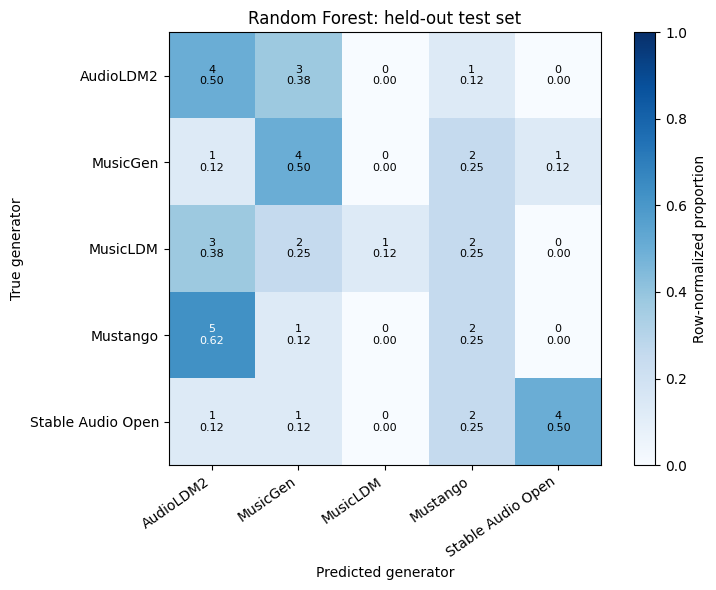

Saved /content/drive/MyDrive/Colab Notebooks/Education/ProgMathsAI/task1_outputs/random_forest/metrics/test_metrics_smoke.json


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
0,0.375,0.375,0.534315,0.375,0.371518


In [9]:
validation_rows = []
trained_models = {}
training_start = time.perf_counter()

for variant_name, model in candidates:
    variant_start = time.perf_counter()
    model.fit(X_train, y_train)
    validation_prediction = model.predict(X_validation)
    metrics = classification_metrics(y_validation, validation_prediction)
    metrics.update({
        "variant": variant_name,
        "runtime_seconds": float(time.perf_counter() - variant_start),
    })
    validation_rows.append(metrics)
    trained_models[variant_name] = model

validation_results = pd.DataFrame(validation_rows).sort_values(
    ["macro_f1", "balanced_accuracy"], ascending=False
).reset_index(drop=True)
display(validation_results)

best_variant = validation_results.iloc[0]["variant"]
best_model = trained_models[best_variant]
test_prediction = best_model.predict(X_test)
test_metrics = classification_metrics(y_test, test_prediction)
parameter_count = int(sum(tree.tree_.node_count for tree in best_model.estimators_))
total_runtime = float(time.perf_counter() - training_start)

payload = {
    "model": "Random Forest",
    "best_variant": best_variant,
    "run_mode": RUN_MODE,
    "selection_metric": "validation_macro_f1",
    "validation": validation_results.iloc[0].to_dict(),
    "test": test_metrics,
    "runtime_seconds": total_runtime,
    "parameter_count": parameter_count,
}

validation_results.to_csv(TABLES_DIR / f"validation_experiments_{RUN_MODE}.csv", index=False)
save_prediction_table(test_paths, y_test, test_prediction,
                      TABLES_DIR / f"test_predictions_{RUN_MODE}.csv")
matrix = plot_confusion(y_test, test_prediction, "Random Forest: held-out test set",
                        FIGURES_DIR / f"test_confusion_{RUN_MODE}.png")
pd.DataFrame(matrix, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    TABLES_DIR / f"test_confusion_{RUN_MODE}.csv"
)
save_json(payload, METRICS_DIR / f"test_metrics_{RUN_MODE}.json")
joblib.dump({"model": best_model, "feature_mean": feature_mean, "feature_std": feature_std}, MODELS_DIR / f"best_model_{RUN_MODE}.joblib")
display(pd.DataFrame([test_metrics]))

## Takeaways

Write the final interpretation only after the full run, using the saved validation table and held-out test metrics.